# Hands-on 0 — Every concept from scratch (no NIFTy yet)

**Course:** NIFTy in a day · **Session:** 08:45 – 10:00

Before using a library you should be able to write a toy version of it yourself. This notebook builds every
idea that NIFTy relies on with nothing but **NumPy** (and JAX for derivatives):

| § | Concept | What you implement |
|---|---|---|
| 1 | Prior, likelihood, posterior, evidence | Bayes' theorem on a grid |
| 2 | MAP, posterior mean, uncertainty | read them off the posterior |
| 3 | Optimizers | gradient descent, Newton, **conjugate gradient** |
| 4 | Fields | a function on a grid, pixel volumes, the continuum limit |
| 5 | Fourier transform / FFT | a DFT by hand, check against `np.fft` |
| 6 | Covariance and power spectrum | why stationary covariances are diagonal in Fourier space |
| 7 | Gaussian random fields | draw one by FFT, verify against Cholesky |
| 8 | Correlated fields (unknown spectrum) | a mini version of NIFTy's correlated field model |
| 9 | Response, noise, data | masks and the measurement equation $d = Rs + n$ |
| 10 | Wiener filter | matrix-free posterior mean + posterior samples |
| 11 | Variational inference (MGVI) | KL minimisation on a 2-D "banana" posterior |

Each section ends with a one-line **"In NIFTy:"** pointer telling you which library object does the same job.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 90

## 1. Prior, likelihood, posterior, evidence

We want to learn an unknown quantity $s$ (the **signal**) from measured **data** $d$.

* **Prior** $P(s)$ — what we believe about $s$ *before* seeing data.
* **Likelihood** $P(d\,|\,s)$ — how probable the observed data are *if* the signal were $s$. It encodes the measurement process and the noise.
* **Posterior** $P(s\,|\,d)$ — what we believe *after* seeing data.
* **Evidence** $P(d) = \int P(d|s)P(s)\,ds$ — the normalisation; useful to compare models.

$$ P(s|d) = \frac{P(d|s)\,P(s)}{P(d)} $$

Physicists like to write it with the **information Hamiltonian** $\mathcal{H}(d,s) = -\ln P(d,s)$:
$P(s|d) \propto e^{-\mathcal{H}(d,s)}$. Minimising $\mathcal{H}$ = maximising the posterior. NIFTy works with $\mathcal{H}$ throughout.

**Example.** A positive quantity $s$ (say a brightness). Prior: log-normal. We measure it 3 times with Gaussian noise $\sigma=0.8$.

data: [3.20058418 2.99431611 3.61233812]


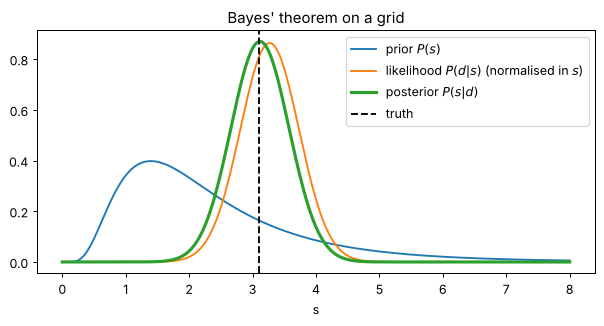

In [2]:
s_grid = np.linspace(1e-3, 8, 2000)
ds = s_grid[1] - s_grid[0]

def lognormal_pdf(s, mu, sig):
    return np.exp(-(np.log(s) - mu) ** 2 / (2 * sig**2)) / (s * sig * np.sqrt(2 * np.pi))

prior = lognormal_pdf(s_grid, mu=np.log(2.0), sig=0.6)

s_true, sigma_n = 3.1, 0.8
d = s_true + sigma_n * rng.normal(size=3)
print("data:", d)

# log-likelihood: independent Gaussian noise on each measurement
log_lh = -0.5 * ((d[:, None] - s_grid[None, :]) ** 2).sum(0) / sigma_n**2
likelihood = np.exp(log_lh - log_lh.max())          # scaled for plotting

unnorm_post = likelihood * prior
evidence = unnorm_post.sum() * ds                   # ∫ P(d|s)P(s) ds (up to the scaling above)
posterior = unnorm_post / evidence

plt.figure(figsize=(8, 3.5))
plt.plot(s_grid, prior, label="prior $P(s)$")
plt.plot(s_grid, likelihood / (likelihood.sum() * ds), label="likelihood $P(d|s)$ (normalised in $s$)")
plt.plot(s_grid, posterior, lw=2.5, label="posterior $P(s|d)$")
plt.axvline(s_true, c="k", ls="--", label="truth")
plt.legend(); plt.xlabel("s"); plt.title("Bayes' theorem on a grid"); plt.show()

**Why not always do this?** A grid over $s$ costs $n^{\dim s}$ points. A $128\times128$ image has 16 384 unknowns —
a grid is impossible. That is the whole reason NIFTy exists: it gives **approximate** posteriors for millions of unknowns.

> **In NIFTy:** prior = a model `s(ξ)` with `ξ ~ N(0,1)`; likelihood = `jft.Gaussian`, `jft.Poissonian`, …; posterior = `Samples` returned by `optimize_kl`.

## 2. Summaries: MAP, posterior mean, uncertainty

In [3]:
s_map = s_grid[np.argmax(posterior)]
s_mean = (s_grid * posterior).sum() * ds
s_std = np.sqrt(((s_grid - s_mean) ** 2 * posterior).sum() * ds)
print(f"MAP = {s_map:.3f}   posterior mean = {s_mean:.3f}   posterior std = {s_std:.3f}   truth = {s_true}")

MAP = 3.118   posterior mean = 3.119   posterior std = 0.458   truth = 3.1


* **MAP** (maximum a posteriori) = the peak. Cheap (just an optimisation), but gives no error bar, and in high dimensions the peak can be very unrepresentative (it over-fits).
* **Posterior mean** minimises the expected squared error. Needs the *whole* posterior — i.e. samples.
* **Posterior std** = uncertainty.

NIFTy's philosophy: always return **samples** from (an approximation of) the posterior, so you can compute any of these and error bars on anything.

## 3. Optimizers: gradient descent, Newton, conjugate gradient

Finding the MAP — and every inner step of NIFTy's algorithms — is an optimisation: minimise an energy $E(x)$.

* **Gradient descent:** $x \leftarrow x - \eta\,\nabla E$. Simple, slow on badly scaled problems.
* **Newton:** $x \leftarrow x - H^{-1}\nabla E$ with the Hessian $H=\nabla\nabla^\top E$. Very fast near the optimum but needs $H^{-1}$.
* **Conjugate gradient (CG):** solves $Ax=b$ for symmetric positive-definite $A$ using *only* products $A v$. Never needs $A$ as a matrix → perfect when $A$ is a huge implicit operator. Equivalent to minimising $\tfrac12 x^\top A x - b^\top x$.
* **Newton-CG** (NIFTy's default): Newton steps, where $H^{-1}\nabla E$ is computed with CG. NIFTy uses the **Fisher metric** in place of $H$ because it is always positive-definite.

### 3.1 Gradient descent vs Newton on a 2-D energy (Rosenbrock-like)

GD after 300 steps   : [0.95903654 0.91636183]  E = 0.0017354402498311557
Newton after 10 steps: [1. 1.]  E = 0.0


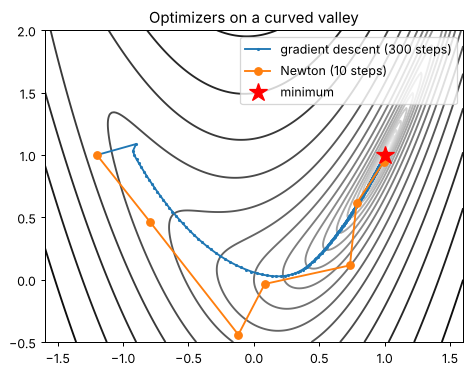

In [4]:
def E(x):
    return (1 - x[0]) ** 2 + 5 * (x[1] - x[0] ** 2) ** 2

gradE = jax.grad(E)
hessE = jax.hessian(E)

def gradient_descent(x0, lr=0.02, n=300):
    xs = [x0]
    for _ in range(n):
        xs.append(xs[-1] - lr * gradE(xs[-1]))
    return jnp.stack(xs)

def newton(x0, n=10):
    xs = [x0]
    for _ in range(n):
        x = xs[-1]
        xs.append(x - jnp.linalg.solve(hessE(x), gradE(x)))
    return jnp.stack(xs)

x0 = jnp.array([-1.2, 1.0])
gd, nt = gradient_descent(x0), newton(x0)
print("GD after 300 steps   :", gd[-1], " E =", E(gd[-1]))
print("Newton after 10 steps:", nt[-1], " E =", E(nt[-1]))

X, Y = np.meshgrid(np.linspace(-1.6, 1.6, 200), np.linspace(-0.5, 2, 200))
Z = (1 - X) ** 2 + 5 * (Y - X**2) ** 2
plt.figure(figsize=(6, 4.5))
plt.contour(X, Y, np.log(Z + 1e-3), 25, cmap="Greys")
plt.plot(*gd.T, ".-", ms=3, label="gradient descent (300 steps)")
plt.plot(*nt.T, "o-", label="Newton (10 steps)")
plt.plot(1, 1, "r*", ms=15, label="minimum")
plt.legend(); plt.title("Optimizers on a curved valley"); plt.show()

### 3.2 Conjugate gradient, written out

In [5]:
def cg(apply_A, b, x0=None, tol=1e-10, maxiter=1000):
    """Solve A x = b for SPD A, using only the function v -> A v."""
    x = np.zeros_like(b) if x0 is None else x0.copy()
    r = b - apply_A(x)                 # residual
    p = r.copy()                       # search direction
    rs = r @ r
    for it in range(maxiter):
        Ap = apply_A(p)
        alpha = rs / (p @ Ap)          # exact line search along p
        x += alpha * p
        r -= alpha * Ap
        rs_new = r @ r
        if np.sqrt(rs_new) < tol:
            return x, it + 1
        p = r + (rs_new / rs) * p      # new direction, A-conjugate to all previous ones
        rs = rs_new
    return x, maxiter

n = 200
M = rng.normal(size=(n, n))
A = M @ M.T / n + np.eye(n)            # random SPD matrix
b = rng.normal(size=n)
x_cg, iters = cg(lambda v: A @ v, b)
print(f"CG converged in {iters} iterations (n = {n}); error vs np.linalg.solve: {np.abs(x_cg - np.linalg.solve(A, b)).max():.2e}")

CG converged in 26 iterations (n = 200); error vs np.linalg.solve: 1.15e-11


> **In NIFTy:** `jft.conjugate_gradient`, `jft.newton_cg`, and the `cg_kwargs` / `minimize_kwargs` you pass to `optimize_kl`. In `nifty.cl`: `ift.ConjugateGradient`, `ift.NewtonCG`, iteration controllers like `ift.AbsDeltaEnergyController`.

## 4. Fields

A **field** is a function over a continuous domain: temperature over a room, mass density over the sky,
brightness over an image. In **Information Field Theory (IFT)** the *signal* is a field, so it has infinitely many degrees of freedom.

On a computer we discretise: a field becomes an array of values on pixels. Two things matter:

1. **The pixel volume** $\Delta V$. Integrals become sums *weighted by volume*: $\int s(x)\,dx \approx \sum_i s_i \Delta V$.
2. **Resolution independence.** If the physics is right, refining the grid must not change the answer. Forgetting $\Delta V$ is the classic bug that makes results depend on the pixel count.

In [6]:
L = 1.0
for N in (16, 64, 256):
    x = (np.arange(N) + 0.5) * L / N           # pixel centres
    dV = L / N
    field = np.sin(2 * np.pi * x) ** 2          # a field on [0, 1)
    print(f"N={N:4d}:  sum(s) = {field.sum():8.3f}   sum(s)*dV = {field.sum() * dV:.4f}   (∫ = 0.5)")

N=  16:  sum(s) =    8.000   sum(s)*dV = 0.5000   (∫ = 0.5)
N=  64:  sum(s) =   32.000   sum(s)*dV = 0.5000   (∫ = 0.5)
N= 256:  sum(s) =  128.000   sum(s)*dV = 0.5000   (∫ = 0.5)


> **In NIFTy:** `nifty.cl` makes this explicit with *domains* (`ift.RGSpace(shape, distances)`, `ift.HPSpace` for the sphere, …) and `ift.Field` = array + domain. `nifty.re` uses plain arrays plus `distances=` arguments.

## 5. The Fourier transform and the FFT

Any field on a periodic grid can be written as a sum of waves:

$$ s_x = \frac{1}{N}\sum_{k} \hat s_k\, e^{2\pi i kx/N}, \qquad \hat s_k = \sum_x s_x\, e^{-2\pi i kx/N}. $$

* $k$ is the **wave number** (harmonic mode): small $|k|$ = large-scale structure, large $|k|$ = fine detail.
* The direct sum costs $O(N^2)$. The **Fast Fourier Transform** reorganises it recursively to $O(N\log N)$ — the reason NIFTy can handle huge fields.
* **Convolution theorem:** convolving (smoothing) in position space = multiplying in Fourier space. That turns most of NIFTy's covariance operations into cheap element-wise products.

In [7]:
def dft(s):
    N = len(s)
    x = np.arange(N)
    k = x[:, None]
    return (s[None, :] * np.exp(-2j * np.pi * k * x / N)).sum(1)

s = rng.normal(size=128)
print("max |DFT - np.fft.fft| =", np.abs(dft(s) - np.fft.fft(s)).max())

import time
big = rng.normal(size=4096)
t = time.perf_counter(); dft(big); t_dft = time.perf_counter() - t
t = time.perf_counter(); np.fft.fft(big); t_fft = time.perf_counter() - t
print(f"N=4096: hand DFT {t_dft * 1e3:.1f} ms vs FFT {t_fft * 1e3:.3f} ms")

# Convolution theorem: periodic smoothing with a Gaussian kernel
N = 256
x = np.arange(N)
signal = (np.abs(x - 128) < 20).astype(float)
dist = np.minimum(x, N - x)                           # periodic distance to 0
kernel = np.exp(-0.5 * (dist / 6) ** 2); kernel /= kernel.sum()
direct = np.array([sum(signal[j] * kernel[(i - j) % N] for j in range(N)) for i in range(N)])
via_fft = np.fft.ifft(np.fft.fft(signal) * np.fft.fft(kernel)).real
print("convolution theorem error:", np.abs(direct - via_fft).max())

max |DFT - np.fft.fft| = 9.052398809225787e-13


N=4096: hand DFT 818.0 ms vs FFT 0.217 ms
convolution theorem error: 4.440892098500626e-16


**The harmonic (k) grid.** `np.fft.fftfreq(N, d=dx)` gives the physical wave number for each FFT entry.
In 2-D, $|k| = \sqrt{k_x^2 + k_y^2}$ — every Fourier pixel has a **mode length**.

**Hartley transform.** NIFTy often uses the Hartley transform $H = \mathrm{Re}\,F + \mathrm{Im}\,F$ instead of the FFT: it maps real arrays to real arrays (no complex bookkeeping) and is its own inverse up to $1/N$.

In [8]:
def hartley(s):
    f = np.fft.fftn(s)
    return f.real + f.imag

z = rng.normal(size=(8, 8))
print("H(H(z)) / N == z ?", np.allclose(hartley(hartley(z)) / z.size, z))

H(H(z)) / N == z ? True


> **In NIFTy:** `jft.correlated_field.hartley`, `grid.harmonic_grid.mode_lengths`; in `nifty.cl`: `ift.HarmonicTransformOperator`, `space.get_default_codomain()`.

## 6. Covariance and the power spectrum

A **Gaussian process / Gaussian field** prior is $s \sim \mathcal{N}(0, S)$ with covariance $S_{xy} = \langle s_x s_y \rangle$.
For an $N$-pixel field, $S$ has $N^2$ entries — $2.7\times10^8$ for a $128^2$ image. Too big to store.

Escape: assume **statistical homogeneity** (stationarity): correlation depends only on the separation, $S_{xy} = C(x-y)$.
Then $S$ is a convolution, and by the convolution theorem it is **diagonal in Fourier space**:

$$ S = F^{-1}\,\mathrm{diag}\big(P(k)\big)\,F . $$

$P(k)$ is the **power spectrum** — the Fourier transform of the correlation function $C$ (Wiener–Khinchin theorem).
If we also assume **isotropy**, $P$ depends only on $|k|$, so an entire $N\times N$ covariance is described by a 1-D function.
Steep spectra ($P \propto k^{-4}$) give smooth fields; flat spectra give noise-like fields.

largest off-diagonal entry of S in Fourier basis: 1.04e-15  -> diagonal!
diagonal == FFT of correlation function ? True


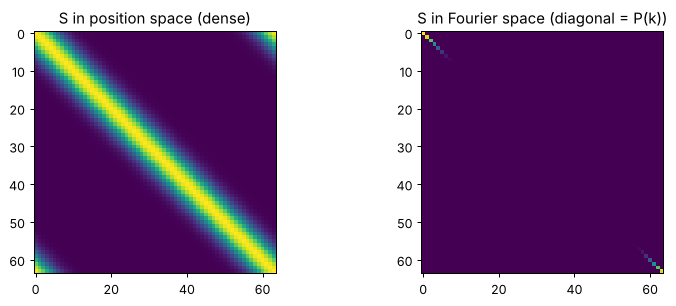

In [9]:
N = 64
x = np.arange(N)
ell = 4.0
C = np.exp(-0.5 * (np.minimum(x, N - x) / ell) ** 2)   # periodic squared-exponential correlation
S = np.array([[C[(i - j) % N] for j in range(N)] for i in range(N)])

F = np.fft.fft(np.eye(N))                                # DFT matrix
S_fourier = F @ S @ np.conj(F.T) / N
off = np.abs(S_fourier - np.diag(np.diag(S_fourier))).max()
print(f"largest off-diagonal entry of S in Fourier basis: {off:.2e}  -> diagonal!")
print("diagonal == FFT of correlation function ?", np.allclose(np.diag(S_fourier).real, np.fft.fft(C).real))

fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))
axs[0].imshow(S); axs[0].set_title("S in position space (dense)")
axs[1].imshow(np.abs(S_fourier)); axs[1].set_title("S in Fourier space (diagonal = P(k))")
plt.tight_layout(); plt.show()

## 7. Drawing Gaussian random fields

If $\xi \sim \mathcal{N}(0, \mathbb{1})$ and $s = A\xi$ then $s \sim \mathcal{N}(0, AA^\top)$. Any "square root" of $S$ works:

* **Cholesky:** $A = \mathrm{chol}(S)$ — $O(N^3)$, fine for 64 pixels, hopeless for $10^6$.
* **Fourier:** $A = F^{-1}\,\mathrm{diag}(\sqrt{P(k)})$ — $O(N\log N)$: generate white noise, multiply by the **amplitude spectrum** $\sqrt{P(k)}$, FFT back.

This is exactly the **standardization** trick: a correlated field is a *deterministic function* $s(\xi)$ of white noise $\xi$.

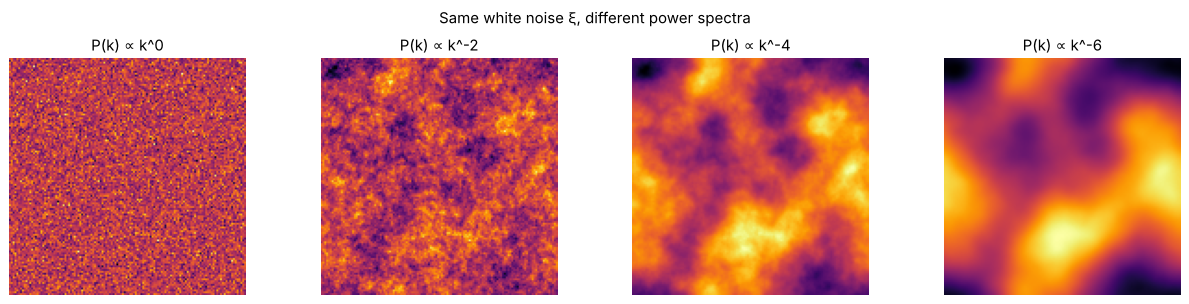

empirical vs true covariance, max abs diff: 0.021
Cholesky gives the same distribution, e.g. var: 0.996


In [10]:
def grf_2d(xi, power_fn, distances=1.0):
    """Gaussian random field from white noise xi via the FFT."""
    kx = np.fft.fftfreq(xi.shape[0], d=distances)
    ky = np.fft.fftfreq(xi.shape[1], d=distances)
    k = np.sqrt(kx[:, None] ** 2 + ky[None, :] ** 2)
    amp = np.sqrt(power_fn(k))
    return np.fft.ifft2(amp * np.fft.fft2(xi)).real

xi = rng.normal(size=(128, 128))
fig, axs = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, slope in zip(axs, [0, -2, -4, -6]):
    P = lambda k, a=slope: (k + 1 / 128) ** a
    ax.imshow(grf_2d(xi, P, 1 / 128), cmap="inferno"); ax.set_title(f"P(k) ∝ k^{slope}"); ax.axis("off")
plt.suptitle("Same white noise ξ, different power spectra"); plt.tight_layout(); plt.show()

# Check in 1-D: the FFT construction has the right covariance (compare with Cholesky / analytic S)
P1 = np.clip(np.fft.fft(C).real, 0, None)   # clip tiny negative round-off
samples = np.array([np.fft.ifft(np.sqrt(P1) * np.fft.fft(rng.normal(size=N))).real for _ in range(20000)])
emp = samples.T @ samples / len(samples)
print("empirical vs true covariance, max abs diff:", np.abs(emp - S).max().round(3))
L_chol = np.linalg.cholesky(S + 1e-9 * np.eye(N))
print("Cholesky gives the same distribution, e.g. var:", (L_chol @ rng.normal(size=(N, 20000))).var(1).mean().round(3))

**Empirical power spectrum.** Given a field, estimate $P(k)$ by averaging $|\hat s_k|^2$ over shells of equal $|k|$.
NIFTy calls the map "pixels → shells" the **power distributor** (and its adjoint averages back).

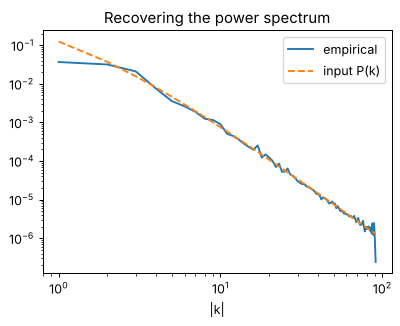

In [11]:
def empirical_power(field):
    f = np.fft.fft2(field) / np.sqrt(field.size)
    kx = np.fft.fftfreq(field.shape[0]) * field.shape[0]
    k = np.sqrt(kx[:, None] ** 2 + kx[None, :] ** 2)
    kbin = np.round(k).astype(int)
    p = np.bincount(kbin.ravel(), (np.abs(f) ** 2).ravel()) / np.bincount(kbin.ravel())
    return np.arange(len(p)), p

field = grf_2d(xi, lambda k: (k + 1) ** -3.0, 1.0 / 128)   # distances=1/N -> k in index units, matching empirical_power
kk, pp = empirical_power(field)
plt.figure(figsize=(5, 3.5)); plt.loglog(kk[1:], pp[1:], label="empirical")
plt.loglog(kk[1:], (kk[1:] + 1) ** -3.0, "--", label="input P(k)"); plt.legend(); plt.xlabel("|k|")
plt.title("Recovering the power spectrum"); plt.show()

> **In NIFTy:** `jft.correlated_field.make_grid(...).harmonic_grid.power_distributor`, `jft.compute_empirical_power_spectrum`; in `nifty.cl`: `ift.PowerSpace`, `ift.PowerDistributor`, `ift.PS_field`.

## 8. Correlated fields with an *unknown* power spectrum

In real problems we don't know $P(k)$. NIFTy's answer — the **correlated field model** — puts a prior on the spectrum
itself and infers it jointly with the field. Its parameters (all inferred, each with a (mean, std) prior):

| parameter | meaning |
|---|---|
| `offset_mean`, `offset_std` | the field's mean value and the uncertainty of the zero mode |
| `fluctuations` | overall standard deviation of the field around its mean |
| `loglogavgslope` | average slope of $\log P$ vs $\log k$ (−4: smooth, −1: rough) |
| `flexibility` | how much $\log P$ may deviate from a straight line (an **integrated Wiener process** in $\log k$) |
| `asperity` | how jagged / peaky those deviations may be |

Below is a deliberately simplified version: $\log A(k) = \text{slope}\cdot\log k + \text{flex}\cdot \mathrm{IWP}(\log k)$, normalised so the field has std = `fluctuations`.

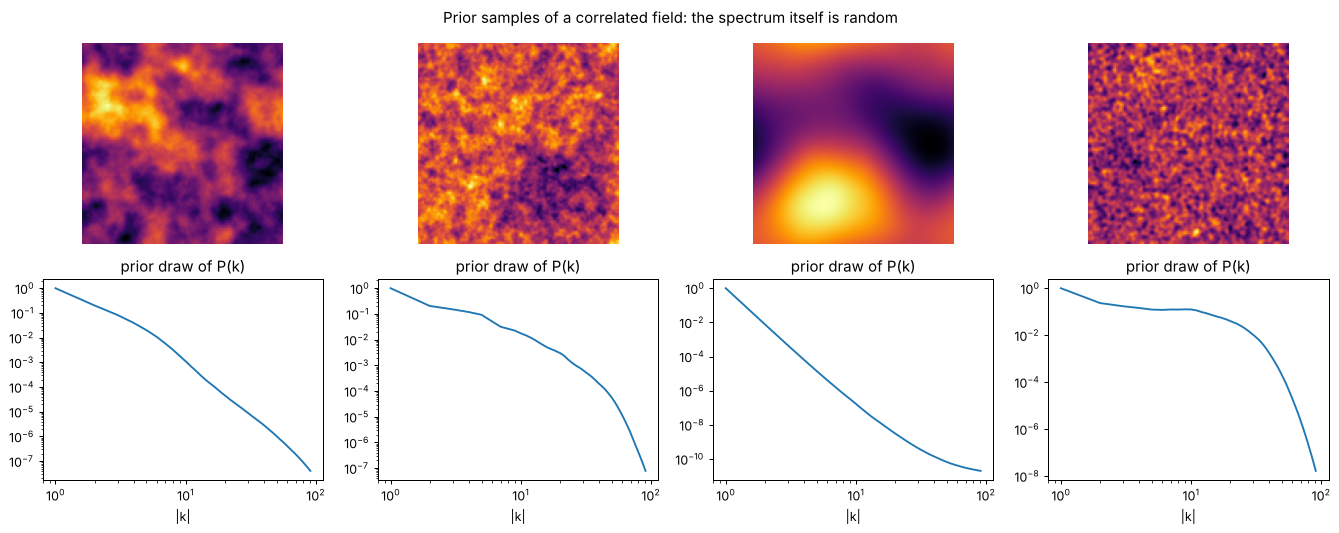

In [12]:
def mini_correlated_field(xi_field, xi_slope, xi_flex, xi_fluct, xi_walk, n=128):
    slope = -2.0 + 0.5 * xi_slope                        # Normal(-2, 0.5) on the log-log slope (amplitude)
    flex = np.exp(np.log(0.6) + 0.5 * xi_flex)           # LogNormal-ish flexibility
    fluct = np.exp(np.log(1.0) + 0.3 * xi_fluct)         # LogNormal-ish fluctuations
    kx = np.fft.fftfreq(n) * n
    kgrid = np.sqrt(kx[:, None] ** 2 + kx[None, :] ** 2)
    kshell = np.arange(1, int(kgrid.max()) + 2)
    t = np.log(kshell)
    dt = np.diff(t, prepend=t[0])
    walk = np.cumsum(np.cumsum(xi_walk[: len(t)] * np.sqrt(dt)) * dt)   # integrated Wiener process
    walk -= np.linspace(walk[0], walk[-1], len(walk))                    # remove its linear trend
    log_amp = slope * t + flex * walk
    amp_shell = np.exp(log_amp)
    amp = np.interp(kgrid, kshell, amp_shell); amp[0, 0] = 0.0          # zero mode handled by offset
    s = np.fft.ifft2(amp * np.fft.fft2(xi_field)).real
    return fluct * s / s.std(), kshell, amp_shell

fig, axs = plt.subplots(2, 4, figsize=(15, 6))
for i in range(4):
    z = rng.normal(size=3)
    f, kshell, a = mini_correlated_field(rng.normal(size=(128, 128)), *z, rng.normal(size=200))
    axs[0, i].imshow(f, cmap="inferno"); axs[0, i].axis("off")
    axs[1, i].loglog(kshell, a ** 2); axs[1, i].set_xlabel("|k|"); axs[1, i].set_title("prior draw of P(k)")
plt.suptitle("Prior samples of a correlated field: the spectrum itself is random"); plt.tight_layout(); plt.show()

Every random ingredient above came from a standard-normal $\xi$. Inference over this model = inferring $\xi_\text{field}$, $\xi_\text{slope}$, $\xi_\text{flex}$, …
all together — the field **and** its correlation structure.

> **In NIFTy:** `jft.CorrelatedFieldMaker` + `.add_fluctuations(...)` + `.finalize()` (re) or `ift.SimpleCorrelatedField` / `ift.CorrelatedFieldMaker` (cl). Hands-on 3 is all about it.

## 9. Response, noise and data

Instruments never see the signal directly. The **measurement equation** is

$$ d = R(s) + n , $$

* $R$ — the **response**: masking, blurring, line-of-sight integration, Fourier sampling (interferometry), exposure, …
* $n$ — **noise**, here $n \sim \mathcal{N}(0, N)$. (For photon counts the likelihood is Poisson instead.)

Linear responses are best written as functions (`apply_R`) together with their **adjoint** $R^\dagger$ (`apply_Rt`) — NIFTy needs both.

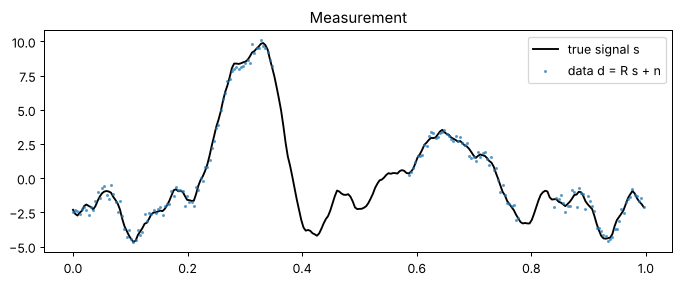

In [13]:
N = 256
x = np.arange(N) / N
P_true = lambda k: 2.0 / (1 + (k / 4) ** 4)            # true power spectrum (k in index units)
k1 = np.abs(np.fft.fftfreq(N) * N)
amp1 = np.sqrt(P_true(k1) * N)                         # include N so that s has O(1) variance

def apply_S_sqrt(xi):  return np.fft.ifft(amp1 * np.fft.fft(xi)).real
def apply_S(v):        return np.fft.ifft(amp1**2 * np.fft.fft(v)).real
def apply_S_inv(v):    return np.fft.ifft(np.fft.fft(v) / amp1**2).real

mask = np.ones(N, bool); mask[90:150] = False; mask[200:215] = False
def apply_R(s):  return s[mask]                        # observe only unmasked pixels
def apply_Rt(d):                                        # adjoint: put data back, zeros elsewhere
    out = np.zeros(N); out[mask] = d; return out

noise_std = 0.3
s_true = apply_S_sqrt(rng.normal(size=N))
data = apply_R(s_true) + noise_std * rng.normal(size=mask.sum())

plt.figure(figsize=(9, 3.2)); plt.plot(x, s_true, "k", label="true signal s")
plt.plot(x[mask], data, ".", ms=3, alpha=0.6, label="data d = R s + n"); plt.legend(); plt.title("Measurement"); plt.show()

## 10. The Wiener filter — the exact posterior for linear Gaussian problems

With prior $s\sim\mathcal{N}(0,S)$, linear response $R$, Gaussian noise $N$, the posterior is Gaussian:

$$ P(s|d) = \mathcal{N}(s;\, m, D), \qquad D = \left(S^{-1} + R^\dagger N^{-1} R\right)^{-1}, \qquad m = D\, j,\quad j = R^\dagger N^{-1} d . $$

* $j$ — the **information source** (data back-projected into signal space).
* $D$ — the **information propagator** = posterior covariance. $D^{-1}$ = prior precision + data precision.
* We never build $D$: we solve $D^{-1} m = j$ with **conjugate gradient**, using only operator applications.

**Posterior samples** without ever forming $D$: draw $\eta = S^{-1/2}\xi_1 + R^\dagger N^{-1/2}\xi_2$ (which has covariance $D^{-1}$), then solve $D^{-1}y = \eta$; $y \sim \mathcal{N}(0, D)$. NIFTy does exactly this — it's how MGVI draws samples too.

In [14]:
def apply_D_inv(v):
    return apply_S_inv(v) + apply_Rt(apply_R(v)) / noise_std**2

j = apply_Rt(data) / noise_std**2
m_naive, it_naive = cg(apply_D_inv, j, tol=1e-6, maxiter=3000)
print("CG iterations, naive signal-space system      :", it_naive)

CG iterations, naive signal-space system      : 550


That took many iterations: $S^{-1}$ has eigenvalues spanning many orders of magnitude (tiny power at high $k$),
so $D^{-1}$ is badly **conditioned**. Fix: solve in **standardized coordinates**. Write $s = A\xi$ with $A = S^{1/2}$; then

$$ D_\xi^{-1} = \mathbb{1} + A^\dagger R^\dagger N^{-1} R A , $$

whose eigenvalues are all $\ge 1$ — beautifully conditioned. This is the **same standardization** that NIFTy imposes on every model.

CG iterations, standardized system            : 130
max difference between the two solutions      : 0.0


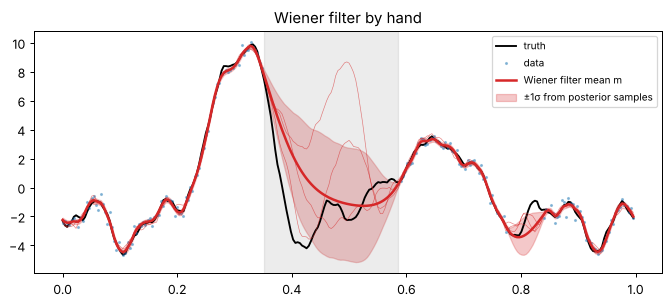

In [15]:
A_ = apply_S_sqrt                                     # symmetric, so A^T = A
def apply_Dxi_inv(v):
    return v + A_(apply_Rt(apply_R(A_(v)))) / noise_std**2

j_xi = A_(apply_Rt(data)) / noise_std**2
m_xi, it_std = cg(apply_Dxi_inv, j_xi, tol=1e-6)
m = A_(m_xi)
print("CG iterations, standardized system            :", it_std)
print("max difference between the two solutions      :", np.abs(m - m_naive).max().round(4))

# Posterior samples in standardized coordinates:
# eta = xi_1 + A R^T N^{-1/2} xi_2 has covariance D_xi^{-1}; solving D_xi^{-1} y = eta gives y ~ N(0, D_xi)
wf_samples = []
for _ in range(60):
    eta = rng.normal(size=N) + A_(apply_Rt(rng.normal(size=mask.sum()) / noise_std))
    y, _ = cg(apply_Dxi_inv, eta, tol=1e-6)
    wf_samples.append(A_(m_xi + y))
wf_samples = np.array(wf_samples)
std = wf_samples.std(0)

plt.figure(figsize=(9, 3.5))
plt.plot(x, s_true, "k", label="truth"); plt.plot(x[mask], data, ".", ms=3, alpha=0.4, label="data")
plt.plot(x, m, "C3", lw=2, label="Wiener filter mean m")
plt.fill_between(x, m - std, m + std, color="C3", alpha=0.25, label="±1σ from posterior samples")
for i in range(3): plt.plot(x, wf_samples[i], "C3", lw=0.5, alpha=0.6)
plt.axvspan(90 / N, 150 / N, color="grey", alpha=0.15); plt.legend(fontsize=8); plt.title("Wiener filter by hand")
plt.show()

Look at the masked region: the mean relaxes towards 0 (the prior mean) and the uncertainty grows — the prior's
correlation structure *interpolates* across the gap, and honestly reports that it is guessing.

> **In NIFTy:** `jft.wiener_filter_posterior` (re); in `nifty.cl` you build `D_inv = R.adjoint @ N.inverse @ R + S.inverse` and invert it with `ift.InversionEnabler` — exactly the formula above. Hands-on 2.

## 11. Variational inference: MGVI from scratch

For non-linear models (e.g. $s=e^{\phi}$, unknown power spectrum, Poisson data) the posterior is not Gaussian.
**Variational inference** picks a simple family $Q$ (Gaussians) and minimises the **Kullback–Leibler divergence**

$$ \mathrm{KL}(Q\,\|\,P) = \int Q(\xi)\ln\frac{Q(\xi)}{P(\xi|d)}\,d\xi = \big\langle \mathcal{H}(d,\xi) \big\rangle_Q - \text{entropy}(Q) + \text{const}. $$

**MGVI** (Metric Gaussian VI) makes this cheap:
1. Take $Q = \mathcal{N}(\bar\xi, M(\bar\xi)^{-1})$ with $M$ the **Fisher metric** + prior precision. The covariance is *not* optimised; it's set by $M$.
2. Draw samples $\xi_i = \bar\xi \pm \delta\xi_i$ from $Q$ (antithetic pairs).
3. Move $\bar\xi$ to minimise the sample average $\frac1n\sum_i\mathcal{H}(d, \xi_i)$ (with $\delta\xi_i$ fixed).
4. Repeat: redraw samples at the new $\bar\xi$.

**geoVI** improves step 2: it bends the samples along the posterior's curvature via a non-linear coordinate transformation, so non-Gaussian shapes are captured much better.

Below: a 2-D "banana" posterior, $d = \xi_1 + \xi_2^2 + n$ (plus a weak direct measurement of $\xi_1$).

MGVI iteration 0: mean = [0.7   0.257]
MGVI iteration 1: mean = [0.791 0.243]
MGVI iteration 2: mean = [1.031 0.279]
MGVI iteration 3: mean = [0.623 0.267]
MGVI iteration 4: mean = [0.583 0.249]
MGVI iteration 5: mean = [0.731 0.17 ]


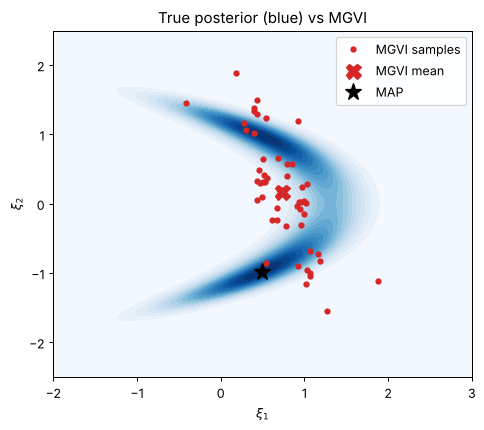

In [16]:
d_obs, sig = 1.5, 0.3
def H(xi):  # information Hamiltonian = -log likelihood - log prior
    r1 = xi[0] + xi[1] ** 2
    return 0.5 * ((d_obs - r1) / sig) ** 2 + 0.5 * ((0.5 - xi[0]) / 1.0) ** 2 + 0.5 * jnp.sum(xi**2)

def jac_resp(xi):  # Jacobian of the data responses, scaled by 1/noise
    return jnp.array([[1 / sig, 2 * xi[1] / sig], [1.0, 0.0]])

def metric(xi):  # Fisher metric of likelihood + identity from the prior
    J = jac_resp(xi)
    return J.T @ J + jnp.eye(2)

gH = jax.jit(jax.grad(H))
key = jax.random.PRNGKey(0)
xbar = jnp.array([0.0, 0.3])
for it in range(6):
    # (2) draw samples from N(0, M(xbar)^{-1}) and mirror them
    key, sk = jax.random.split(key)
    Lc = jnp.linalg.cholesky(jnp.linalg.inv(metric(xbar)))
    dxi = (Lc @ jax.random.normal(sk, (2, 25))).T
    dxi = jnp.concatenate([dxi, -dxi])
    # (3) minimise the sample-averaged energy with a few Newton steps, using the averaged metric
    for _ in range(5):
        g = jnp.mean(jax.vmap(lambda d_: gH(xbar + d_))(dxi), 0)
        Mbar = jnp.mean(jax.vmap(lambda d_: metric(xbar + d_))(dxi), 0)
        xbar = xbar - jnp.linalg.solve(Mbar, g)
    print(f"MGVI iteration {it}: mean = {np.round(np.array(xbar), 3)}")
mgvi_samples = xbar + dxi

# Ground truth: the exact posterior on a grid
g1, g2 = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-2.5, 2.5, 300))
Hgrid = jax.vmap(jax.vmap(lambda a, b: H(jnp.array([a, b]))))(g1, g2)
post = np.exp(-(Hgrid - Hgrid.min()))
xi_map = g1.ravel()[np.argmax(post)], g2.ravel()[np.argmax(post)]

plt.figure(figsize=(6, 5))
plt.contourf(g1, g2, post, 20, cmap="Blues")
plt.plot(*np.array(mgvi_samples).T, "o", c="C3", ms=4, label="MGVI samples")
plt.plot(*xbar, "X", c="C3", ms=12, label="MGVI mean")
plt.plot(*xi_map, "k*", ms=14, label="MAP")
plt.xlabel(r"$\xi_1$"); plt.ylabel(r"$\xi_2$"); plt.legend(); plt.title("True posterior (blue) vs MGVI")
plt.show()

Notice the mean jitters between iterations: the KL is estimated from a *finite* set of samples that is redrawn
every iteration (stochastic optimisation). More samples → less jitter; NIFTy typically increases `n_samples` in later iterations.

The posterior is bimodal-ish/banana shaped; MGVI's Gaussian can only cover it approximately — and MAP sits at one point
with no error bar at all. In Hands-on 4 you'll see geoVI and HMC/NUTS on the same kind of problem using NIFTy.

> **In NIFTy:** `jft.optimize_kl(..., sample_mode="linear_resample")` = MGVI; `"nonlinear_resample"` = geoVI; `lh.metric` = the Fisher metric; `jft.blackjax_nuts` = exact sampling for comparison.

## Concept → NIFTy cheat sheet

| Concept (this notebook) | `nifty.re` | `nifty.cl` |
|---|---|---|
| Prior via standardization $s(\xi)$ | `jft.NormalPrior`, `jft.LogNormalPrior`, … ; `jft.Model` | `ift.NormalTransform`, `ift.LognormalTransform`, operators |
| Field on a grid | JAX array + `distances` | `ift.Field` on `ift.RGSpace`, `ift.HPSpace` |
| FFT / Hartley | `jft.correlated_field.hartley` | `ift.HarmonicTransformOperator` |
| Power spectrum, shells | `grid.harmonic_grid.power_distributor` | `ift.PowerSpace`, `ift.PowerDistributor` |
| Gaussian random field | `FixedPowerCorrelatedField` pattern (HO2) | `ift.makeOp(PD(PS_field))` + `HT` |
| Correlated field (learned spectrum) | `jft.CorrelatedFieldMaker` | `ift.SimpleCorrelatedField` |
| Response $R$ | any JAX function inside your `Model` | `ift.LinearOperator` (needs adjoint) |
| Likelihood | `jft.Gaussian`, `jft.Poissonian`, `jft.VariableCovarianceGaussian` | `ift.GaussianEnergy`, `ift.PoissonianEnergy` |
| Conjugate gradient / Newton-CG | `jft.conjugate_gradient`, `jft.newton_cg` | `ift.ConjugateGradient`, `ift.NewtonCG` |
| Wiener filter | `jft.wiener_filter_posterior` | `ift.InversionEnabler(D_inv).inverse` |
| Fisher metric | `lh.metric` | `energy.metric` |
| MGVI / geoVI | `jft.optimize_kl(sample_mode=...)` | `ift.optimize_kl` |
| Exact sampling | `jft.blackjax_nuts`, `jft.HMCChain` | — |

## ✏️ Exercises
1. In §1 change the prior to a Normal with mean 2 and std 0.5. How far does the posterior move? Now take 30 data points instead of 3 — what happens to the prior's influence?
2. In §3.2 make `A` badly conditioned (`A = M @ M.T / n + 1e-4 * np.eye(n)`). How many CG iterations now? (This is why NIFTy's preconditioning / standardization matters.)
3. In §7 draw a 2-D field with $P(k) \propto (1 + (k/k_0)^2)^{-2}$ (Matérn-like) for $k_0 = 2, 10, 40$ and describe what $k_0$ controls.
4. In §10 shrink `noise_std` to 0.05, then grow it to 2. Explain what happens to $m$ in both regimes using $D = (S^{-1} + R^\dagger N^{-1}R)^{-1}$.
5. In §10 use a *wrong* power spectrum (10× too small). What does the Wiener filter do? This motivates learning the spectrum (§8).